字體設定完成！


Building prefix dict from /content/dict.txt ...
DEBUG:jieba:Building prefix dict from /content/dict.txt ...
Loading model from cache /tmp/jieba.ueb620ec8402181953a0299d7957c0d6e.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.ueb620ec8402181953a0299d7957c0d6e.cache
Loading model cost 2.203 seconds.
DEBUG:jieba:Loading model cost 2.203 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


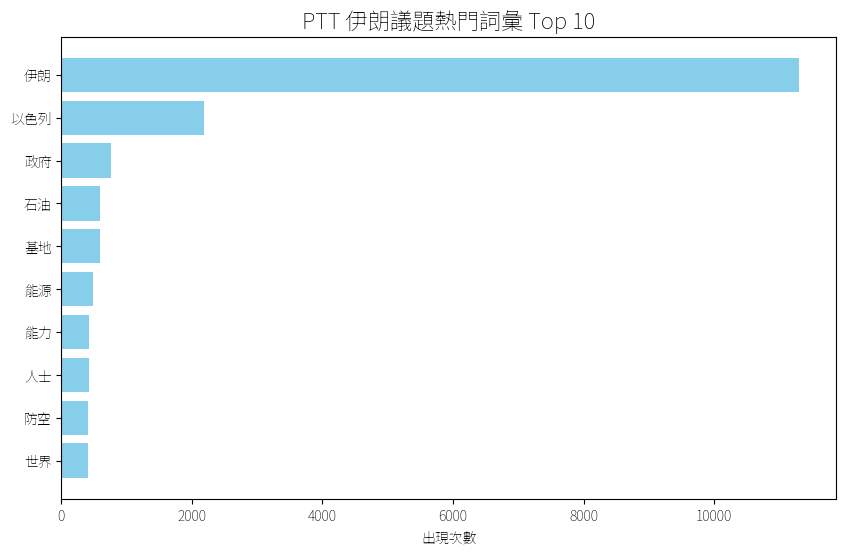

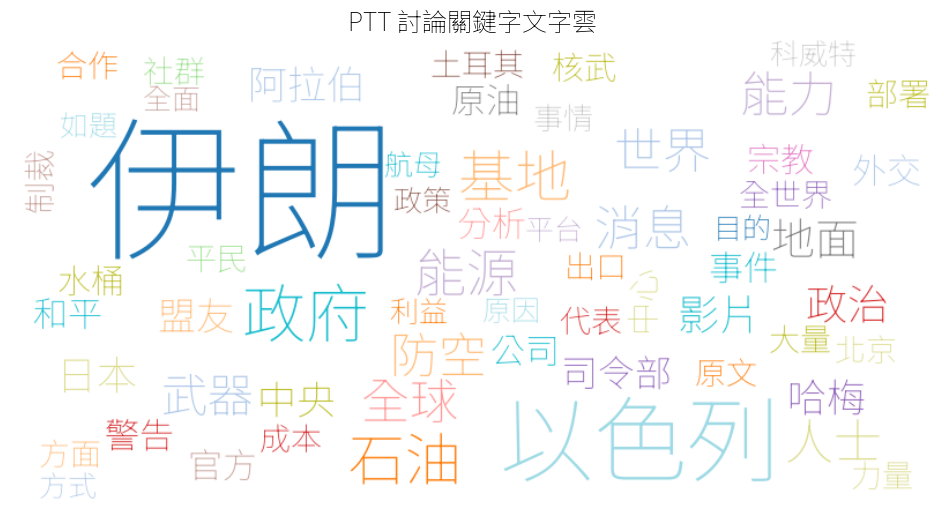


--- 檢查前 20 名高頻詞 ---
   word  count
0    伊朗  11306
1   以色列   2182
2    政府    765
3    石油    595
4    基地    592
5    能源    485
6    能力    418
7    人士    416
8    防空    410
9    世界    409
10   全球    406
11   消息    403
12   武器    358
13   地面    331
14   政治    289
15   影片    286
16   日本    270
17  阿拉伯    260
18   哈梅    259
19   中央    253


In [9]:
import pandas as pd
import jieba
import jieba.posseg as pseg # 引入詞性標註模組
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# --- 1. 字體下載與設定 (Google Colab 專用) ---
if not os.path.exists('font.ttf'):
    !wget -O font.ttf https://github.com/google/fonts/raw/main/ofl/notosanstc/NotoSansTC%5Bwght%5D.ttf

font_path = './font.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
print("字體設定完成！")

# --- 2. 讀取與基本清洗 ---
df = pd.read_csv('/content/ptt_iran_20260301_0320_full.csv')
clear_df = df.copy()

# 去除不需要的欄位與空值
drop_cols = ['system_id', 'artCatagory', 'artUrl', 'artPoster', 'artDate', 'insertedDate']
clear_df.drop(drop_cols, axis=1, inplace=True, errors='ignore')
clear_df.dropna(subset=['artContent'], inplace=True)

# --- 3. PTT 專屬進階文字清理 ---
def clean_ptt_text(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # 移除網址
    text = re.sub(r'※ 發信站: 批踢踢實業坊\(ptt\.cc\).*', '', text) # 移除 PTT 簽名檔
    text = re.sub(r'引述《.*》之銘言', '', text) # 移除引言宣告
    text = re.sub(r'\[.*?\]', '', text) # 移除 [新聞]、[爆卦] 這種標籤
    text = re.sub(r'[a-zA-Z0-9]+', '', text) # 移除純英文和數字 (如 XD, ID)
    text = re.sub(r'\n+', '。', text) # 換行轉句號
    return text

clear_df['sentence'] = clear_df['artContent'].apply(clean_ptt_text)

# 斷句
clear_df['sentence'] = clear_df['sentence'].str.split(r"[,，。！!？?]+")
sent_df = clear_df.explode('sentence').reset_index(drop=True)
sent_df = sent_df[sent_df["sentence"].str.len() > 1] # 移除過短的句子

# --- 4. 斷詞與詞性篩選 (核心優化區) ---
# 初始化字典與強制合體詞 (請根據伊朗議題補充)
jieba.set_dictionary('/content/dict.txt')

# 針對本次伊朗議題
custom_words = ['防衛隊', '革命衛隊', '無人機', '核設施', '哈瑪斯', '真主黨', '中東', '大馬士革', '德黑蘭']
for w in custom_words:
    jieba.add_word(w)

# 定義我們要保留的詞性 (名詞系列)
# n:一般名詞, nr:人名, ns:地名, nt:機構名, nz:其他專有名詞, vn:名動詞
allowed_flags = ['n', 'nr', 'ns', 'nt', 'nz', 'vn']

def get_keywords(text):
    # 使用 posseg 進行帶詞性的斷詞
    words = pseg.cut(text)
    # 過濾條件：長度>=2，且詞性在允許清單內
    return [w.word for w in words if len(w.word) >= 2 and w.flag in allowed_flags]

# 執行斷詞與過濾 (這步會稍微花一點時間)
word_df = sent_df.assign(word=sent_df['sentence'].apply(get_keywords)).explode('word').dropna(subset=['word'])

# --- 5. 最終停用字過濾 ---
# 讀取你的停用字檔
try:
    with open('/content/stopwords.txt', 'r', encoding='utf-8') as f:
        stopwords = set([line.strip() for line in f])
except FileNotFoundError:
    stopwords = set()

# 手動補充 (因為前面已經用詞性濾掉大部分廢話，這裡只需要濾掉「名詞類」的廢話)
stopwords_manual = {"新聞", "文章", "標題", "報導", "八卦", "看板", "作者", "時間", "來源", "內容", "媒體", "情況", "問題"}
stopwords.update(stopwords_manual)

# 執行最後過濾
noStop_df = word_df[~word_df['word'].isin(stopwords)]

# --- 6. 計算詞頻與繪圖 ---
freq_df_nostop = noStop_df['word'].value_counts().reset_index()
freq_df_nostop.columns = ['word', 'count']

freq_dict = freq_df_nostop.set_index('word').to_dict()['count']

# 繪製長條圖
top_10_words = freq_df_nostop.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10_words['word'], top_10_words['count'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("PTT 伊朗議題熱門詞彙 Top 10", fontproperties=prop, fontsize=16)
plt.xlabel("出現次數", fontproperties=prop)
plt.show()

# 繪製文字雲
wordcloud = WordCloud(
    background_color='white',
    width=800,
    height=400,
    font_path=font_path,
    max_words=60,
    colormap='tab20'
)
wordcloud.generate_from_frequencies(freq_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("PTT 討論關鍵字文字雲", fontproperties=prop, fontsize=18)
plt.show()

# 印出前20名檢查
print("\n--- 檢查前 20 名高頻詞 ---")
print(freq_df_nostop.head(20))